**<h1>AHJ Database: Test Notebook**
#### Use this for testing code
<i>Any question regarding the notebook, please contact Robert Ford<br>
    Last Updated: 09/09/2025</i>
* Current test is for generating map of attendees 

In [133]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from collections import Counter


In [134]:
# List of jurisdictions with participant counts
jurisdictions = [
    "Murrieta", "San Diego", "El Centro", "Hayward", "Los Angeles", "Eureka", "San Marcos", "Santa Barbara",
    "Wasco", "Redding", "Garden Grove", "Newport Beach", "Wildomar", "Palo Alto", "El Dorado", "Santa Maria",
    "San Francisco", "Berkeley", "Pomona", "Turlock", "Half Moon Bay", "Los Altos Hills", "Davis", "Dixon",
    "San Bernardino", "Tiburon", "San Bernardino", "Pismo Beach", "Folsom", "San Diego", "Eureka", "Orland",
     "Folsom", "San Diego", "Folsom", "Riverside", "Eureka"
]

In [135]:
# Count the occurrences of each jurisdiction
jurisdiction_counts = Counter(jurisdictions)

# Load California shapefile (replace with your shapefile path)
#california_shapefile = 'C:/Users/Rford/OneDrive - California Energy Commission/Documents/Analysis - Scripts and Code/AHJ-Database/data/external/California_County_Boundaries_and_Identifiers/California_County_Boundaries_and_Identifiers.shp'  # Modify with your file location
#california_shapefile = 'C:/Users/Rford/OneDrive - California Energy Commission/Documents/Analysis - Scripts and Code/AHJ-Database/data/external/California_Incorporated_Cities/California_Incorporated_Cities.shp'  # Modify with your file location
california_shapefile = 'C:/Users/Rford/OneDrive - California Energy Commission/Documents/Analysis - Scripts and Code/AHJ-Database/data/external/City_and_County_Boundary_Line_Changes/BOE_CityCounty.shp'  # Modify with your file location

california = gpd.read_file(california_shapefile)

# You may need to inspect the shapefile columns to match with the relevant one (e.g., 'NAME', 'CITY_NAME', etc.)
jurisdiction_column = 'CITY'  # Adjust this depending on the shapefile's column for city names
cities = california[california[jurisdiction_column].isin(jurisdiction_counts.keys())]

# Add a simple color-coding scheme for the jurisdictions
color_map = plt.cm.get_cmap('viridis', len(jurisdiction_counts))  # Use a colormap with distinct colors
color_dict = {jurisdiction: color_map(i) for i, jurisdiction in enumerate(jurisdiction_counts)}




C:\Users\Rford\AppData\Local\Temp\ipykernel_32988\2098034330.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap('viridis', len(jurisdiction_counts))  # Use a colormap with distinct colors


In [136]:
print("Jurisdiction Counts:", jurisdiction_counts)
# Inspect the columns and first few rows of the shapefile
print(california.columns)
print(california.head())

# Check the unique values in the 'jurisdiction_column' (usually 'NAME' or similar)
print(california[jurisdiction_column].unique())

Jurisdiction Counts: Counter({'San Diego': 3, 'Eureka': 3, 'Folsom': 3, 'San Bernardino': 2, 'Murrieta': 1, 'El Centro': 1, 'Hayward': 1, 'Los Angeles': 1, 'San Marcos': 1, 'Santa Barbara': 1, 'Wasco': 1, 'Redding': 1, 'Garden Grove': 1, 'Newport Beach': 1, 'Wildomar': 1, 'Palo Alto': 1, 'El Dorado': 1, 'Santa Maria': 1, 'San Francisco': 1, 'Berkeley': 1, 'Pomona': 1, 'Turlock': 1, 'Half Moon Bay': 1, 'Los Altos Hills': 1, 'Davis': 1, 'Dixon': 1, 'Tiburon': 1, 'Pismo Beach': 1, 'Orland': 1, 'Riverside': 1})
Index(['COUNTY', 'CITY', 'COPRI', 'created_us', 'created_da', 'last_edite',
       'last_edi_1', 'CreationDa', 'Creator', 'EditDate', 'Editor',
       'geometry'],
      dtype='object')
           COUNTY        CITY  COPRI created_us created_da last_edite  \
0  Alameda County     Alameda  01021       None 1899-12-30       None   
1  Alameda County      Albany  01022       None 1899-12-30       None   
2  Alameda County    Berkeley  01013       None 1899-12-30       None   
3  Alamed

In [137]:
# Check if the jurisdictions in your list are present in the shapefile
missing_jurisdictions = [jurisdiction for jurisdiction in jurisdiction_counts if jurisdiction not in california[jurisdiction_column].values]
print("Missing Jurisdictions:", missing_jurisdictions)

# Check the geometry types in the shapefile
print(california.geometry.geom_type.value_counts())

Missing Jurisdictions: ['El Dorado']
Polygon         1510
MultiPolygon      13
Name: count, dtype: int64


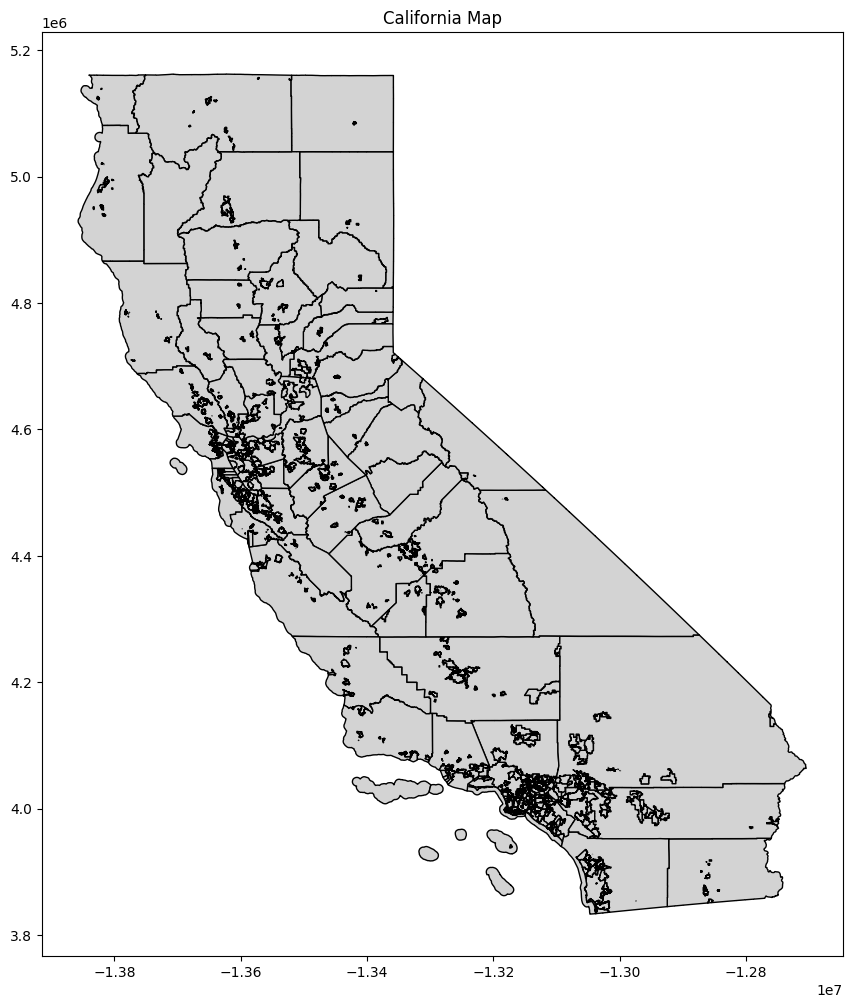

In [138]:
# Plot the entire shapefile first to check if the map appears
fig, ax = plt.subplots(figsize=(12, 12))
california.plot(ax=ax, color='lightgrey', edgecolor='black')
ax.set_title('California Map')
plt.show()


['Berkeley' 'Hayward' 'Orland' 'Eureka' 'El Centro' 'Wasco' 'Los Angeles'
 'Pomona' 'Tiburon' 'Garden Grove' 'Newport Beach' 'Murrieta' 'Riverside'
 'Wildomar' 'Folsom' 'San Bernardino' 'San Diego' 'San Marcos'
 'San Francisco' 'Half Moon Bay' 'Santa Barbara' 'Santa Maria'
 'Los Altos Hills' 'Palo Alto' 'Redding' 'Dixon' 'Turlock' 'Davis'
 'Pismo Beach']


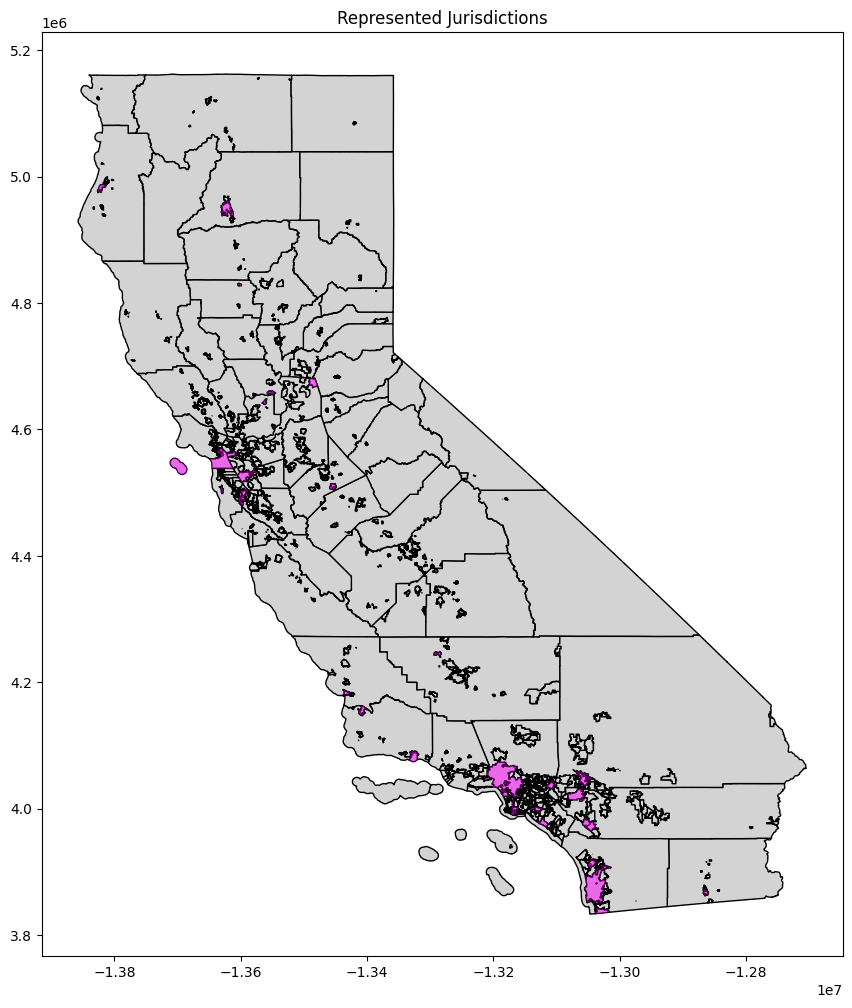

In [139]:
# Print the cities that we are attempting to plot
print(cities[jurisdiction_column].unique())

# Plot the base map again to check the cities we want to visualize
fig, ax = plt.subplots(figsize=(12, 12))
california.plot(ax=ax, color='lightgrey', edgecolor='black')

# Highlight the selected cities (jurisdictions) in the shapefile
cities.plot(ax=ax, color='magenta', alpha=0.5)
ax.set_title('Represented Jurisdictions')
plt.show()


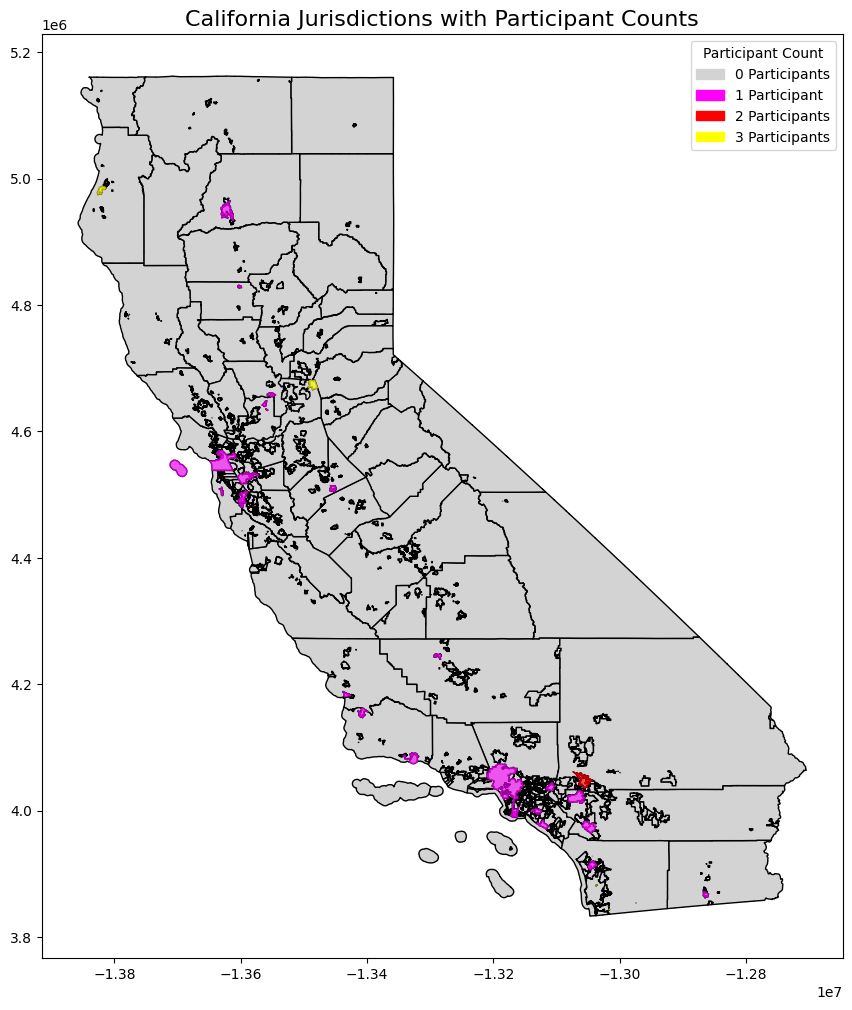

In [140]:
# Define color mapping for counts 0, 1, 2, 3 (using distinct colors)
color_dict2 = {
    0: 'lightgrey',    # For jurisdictions with 0 participants
    1: 'magenta',    # For jurisdictions with 1 participant
    2: 'red',       # For jurisdictions with 2 participants
    3: 'yellow'       # For jurisdictions with 3 participants
}

# Plot the base map
fig, ax = plt.subplots(figsize=(12, 12))
california.plot(ax=ax, color='lightgrey', edgecolor='black')

# Plot cities with color based on the number of participants
for _, city in cities.iterrows():
    city_name = city[jurisdiction_column]
    count = jurisdiction_counts.get(city_name, 0)  # Get participant count for this city
    color = color_dict2.get(count, 'lightgrey')  # Get the color based on the count
    
    # Plot the city boundary with color
    if city.geometry.geom_type == 'Polygon':
        ax.fill(city.geometry.exterior.xy[0], city.geometry.exterior.xy[1], color=color, alpha=0.6)
    elif city.geometry.geom_type == 'MultiPolygon':
        for polygon in city.geometry.geoms:
            ax.fill(polygon.exterior.xy[0], polygon.exterior.xy[1], color=color, alpha=0.6)

# Add title and labels
ax.set_title('California Jurisdictions with Participant Counts', fontsize=16)

# Add legend to indicate the meaning of the colors
# Create custom handles for the legend with color and count labels
legend_labels = [mpatches.Patch(color=color_dict2[0], label="0 Participants"),
                 mpatches.Patch(color=color_dict2[1], label="1 Participant"),
                 mpatches.Patch(color=color_dict2[2], label="2 Participants"),
                 mpatches.Patch(color=color_dict2[3], label="3 Participants")]

plt.legend(handles=legend_labels, loc='upper right', fontsize=10, title="Participant Count")

# Show the map
plt.show()

C:\Users\Rford\AppData\Local\Temp\ipykernel_32988\1212303673.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap('viridis', len(jurisdiction_counts))  # Using a colormap with distinct colors


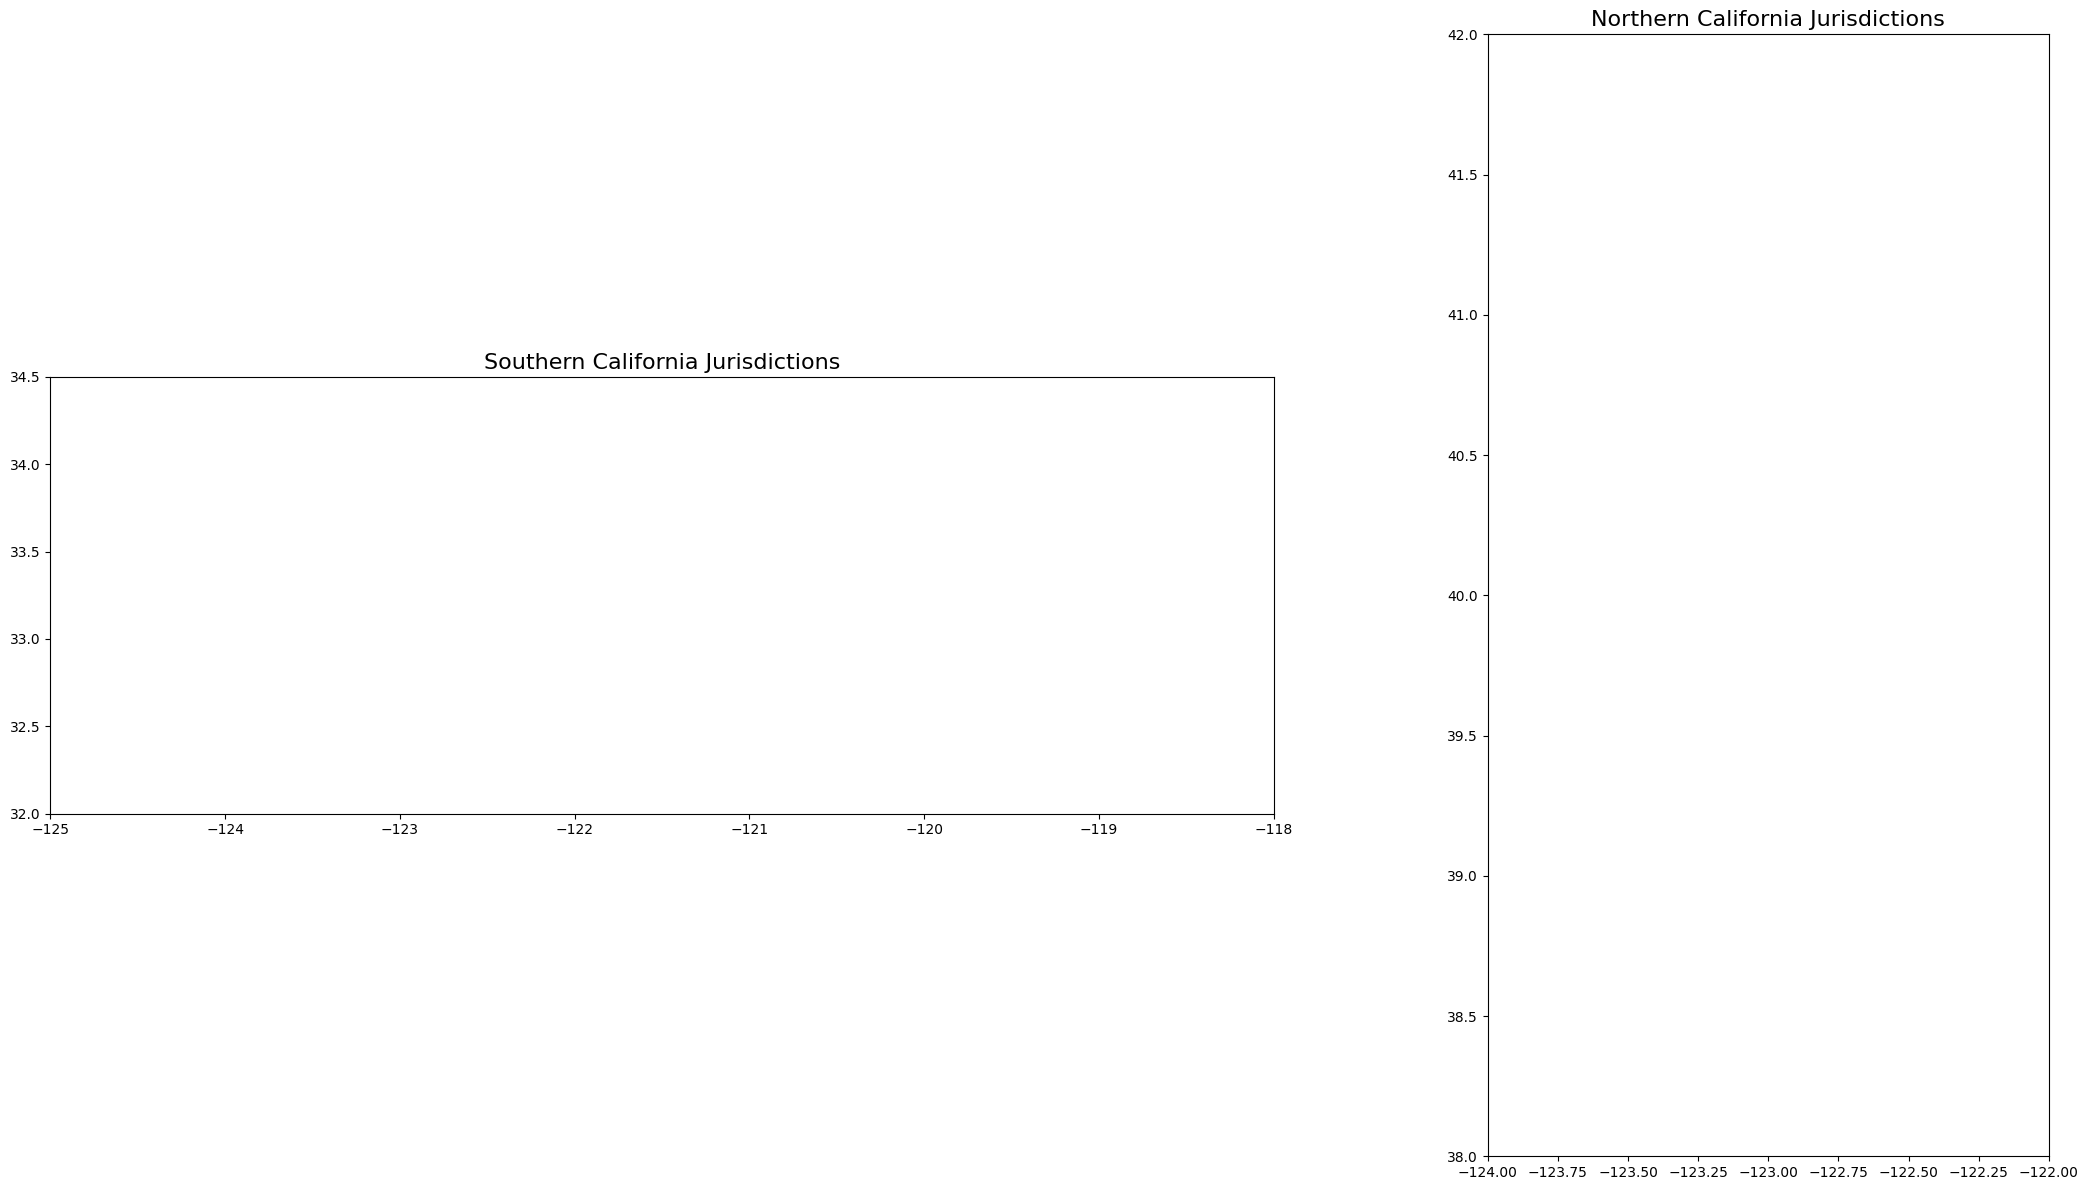

In [141]:
import geopandas as gpd
import matplotlib.pyplot as plt
from collections import Counter

# List of jurisdictions with participant counts (duplicates included)
jurisdictions = [
    "Murrieta", "San Diego", "El Centro", "Hayward", "Los Angeles", "Eureka", "San Marcos", "Santa Barbara County",
    "Wasco", "Redding", "Garden Grove", "Newport Beach", "Wildomar", "Palo Alto", "El Dorado County", "Santa Maria",
    "San Francisco", "Berkeley", "Pomona", "Turlock", "Half Moon Bay", "Los Altos Hills", "Davis", "Dixon",
    "San Bernardino", "Tiburon", "Pismo Beach", "Folsom", "Riverside", "Orland",
    "Afshin Khosraviani", "Eric Driever", "Brendan Reilly", "Orland Building Official", "Jason Rojo", "Aseem Gupta",
    "Marc Underwood", "Chad Phillips", "Sarah Chaffee"
]

# Count the occurrences of each jurisdiction
jurisdiction_counts = Counter(jurisdictions)

# Load the California shapefile (replace with your shapefile path)
#california_shapefile = 'path/to/your/california_shapefile.shp'  # Modify with your file location
#california = gpd.read_file(california_shapefile)

# Filter the data to focus only on the jurisdictions we care about
jurisdiction_column = 'CITY'  # Adjust this depending on the shapefile's column for city names
cities = california[california[jurisdiction_column].isin(jurisdiction_counts.keys())]

# Color-coding for the jurisdictions
color_map = plt.cm.get_cmap('viridis', len(jurisdiction_counts))  # Using a colormap with distinct colors
color_dict = {jurisdiction: color_map(i) for i, jurisdiction in enumerate(jurisdiction_counts)}

# Plot the entire map
fig, axes = plt.subplots(1, 2, figsize=(24, 12))  # Create two subplots side by side

# Southern California plot
ax1 = axes[0]
california.plot(ax=ax1, color='lightgrey')
for _, city in cities.iterrows():
    city_name = city[jurisdiction_column]
    count = jurisdiction_counts.get(city_name, 0)  # Get participant count for this city
    color = color_dict.get(city_name, 'grey')  # Get the color based on the count
    
    # Plot the city boundary with color
    if city.geometry.geom_type == 'Polygon':
        ax1.fill(city.geometry.exterior.xy[0], city.geometry.exterior.xy[1], color=color, alpha=0.6)
    elif city.geometry.geom_type == 'MultiPolygon':
        for polygon in city.geometry.geoms:
            ax1.fill(polygon.exterior.xy[0], polygon.exterior.xy[1], color=color, alpha=0.6)

# Set the zoom limits for Southern California
ax1.set_xlim([-125, -118])  # Longitude limits for Southern California
ax1.set_ylim([32, 34.5])    # Latitude limits for Southern California
ax1.set_title('Southern California Jurisdictions', fontsize=16)

# Northern California plot
ax2 = axes[1]
california.plot(ax=ax2, color='lightgrey')
for _, city in cities.iterrows():
    city_name = city[jurisdiction_column]
    count = jurisdiction_counts.get(city_name, 0)  # Get participant count for this city
    color = color_dict.get(city_name, 'grey')  # Get the color based on the count
    
    # Plot the city boundary with color
    if city.geometry.geom_type == 'Polygon':
        ax2.fill(city.geometry.exterior.xy[0], city.geometry.exterior.xy[1], color=color, alpha=0.6)
    elif city.geometry.geom_type == 'MultiPolygon':
        for polygon in city.geometry.geoms:
            ax2.fill(polygon.exterior.xy[0], polygon.exterior.xy[1], color=color, alpha=0.6)

# Set the zoom limits for Northern California
ax2.set_xlim([-124, -122])  # Longitude limits for Northern California
ax2.set_ylim([38, 42])      # Latitude limits for Northern California
ax2.set_title('Northern California Jurisdictions', fontsize=16)

# Show the final map with both southern and northern regions
plt.tight_layout()  # Adjust layout for better spacing
plt.show()

